In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
%matplotlib inline
import seaborn as sns
import tensorflow as tf

print(tf.__version__)

from google.colab import drive
drive.mount('/content/ColabNotebooks')


2.20.0
Mounted at /content/ColabNotebooks


In [3]:
data_path = '/content/ColabNotebooks/MyDrive/ColabNotebooks/train-data.csv'
car_dataset = pd.read_csv(data_path)
car_dataset.head()

car_dataset.isnull().mean()

,0
Unnamed: 0,0.000000
Name,0.000000
Location,0.000000
Year,0.000000
Kilometers_Driven,0.000000
Fuel_Type,0.000000
Transmission,0.000000
Owner_Type,0.000000
Mileage,0.000332
Engine,0.005981


In [4]:
car_dataset = car_dataset.drop(['Unnamed: 0', 'New_Price'], axis=1)
car_dataset.head()



,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price
0,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,First,26.6 km/kg,998 CC,58.16 bhp,5.0,1.75
1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.0,12.50
2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,18.2 kmpl,1199 CC,88.7 bhp,5.0,4.50
3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77 kmpl,1248 CC,88.76 bhp,7.0,6.00
4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.2 kmpl,1968 CC,140.8 bhp,5.0,17.74


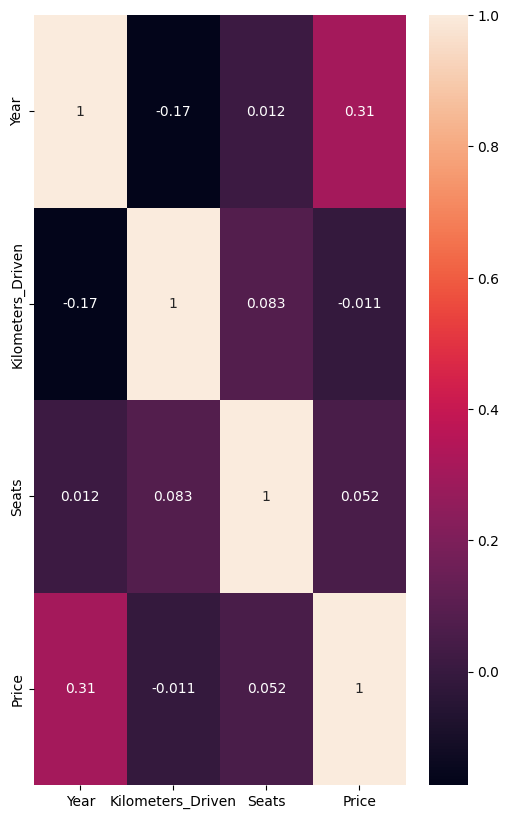

In [5]:
plt.rcParams['figure.figsize'] = [6,10]
sns.heatmap(car_dataset.select_dtypes(include=np.number).corr(), annot=True)
plt.show()

/tmp/ipykernel_10571/1540956848.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(car_dataset['Price'])


<Axes: xlabel='Price', ylabel='Density'>

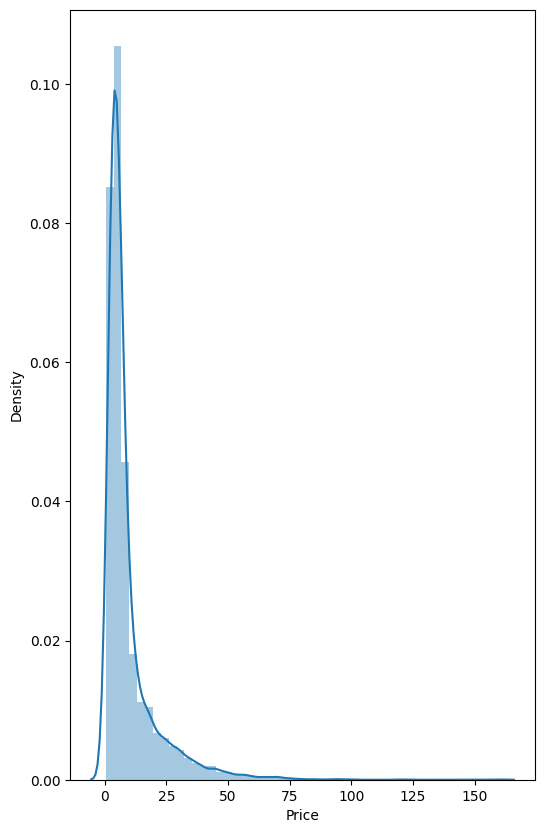

In [6]:
sns.distplot(car_dataset['Price'])
#plt.show()

In [7]:
car_dataset.nunique()

,0
Name,1876
Location,11
Year,22
Kilometers_Driven,3093
Fuel_Type,5
Transmission,2
Owner_Type,4
Mileage,442
Engine,146
Power,372


In [8]:
print(car_dataset.dtypes)

Name                  object
Location              object
Year                   int64
Kilometers_Driven      int64
Fuel_Type             object
Transmission          object
Owner_Type            object
Mileage               object
Engine                object
Power                 object
Seats                float64
Price                float64
dtype: object


In [9]:
numerical_data = car_dataset.drop(['Name' , 'Location' , 'Fuel_Type' , 'Transmission' , 'Owner_Type' ,
'Mileage' , 'Engine' , 'Power'], axis=1)

numerical_data.head()

,Year,Kilometers_Driven,Seats,Price
0,2010,72000,5.0,1.75
1,2015,41000,5.0,12.50
2,2011,46000,5.0,4.50
3,2012,87000,7.0,6.00
4,2013,40670,5.0,17.74


In [10]:
categarical_data = car_dataset.filter(['Location' , 'Fuel_Type' , 'Transmission' , 'Owner_Type' , 'Mileage'
 , 'Engine' , 'Power'], axis=1)
categarical_data.head()

,Location,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power
0,Mumbai,CNG,Manual,First,26.6 km/kg,998 CC,58.16 bhp
1,Pune,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp
2,Chennai,Petrol,Manual,First,18.2 kmpl,1199 CC,88.7 bhp
3,Chennai,Diesel,Manual,First,20.77 kmpl,1248 CC,88.76 bhp
4,Coimbatore,Diesel,Automatic,Second,15.2 kmpl,1968 CC,140.8 bhp


In [11]:
categarical_data_one_hot = pd.get_dummies(categarical_data, drop_first=True)
categarical_data_one_hot.head()

,Location_Bangalore,Location_Chennai,Location_Coimbatore,Location_Delhi,Location_Hyderabad,Location_Jaipur,Location_Kochi,Location_Kolkata,Location_Mumbai,Location_Pune,...,Power_97.6 bhp,Power_97.7 bhp,Power_98.59 bhp,Power_98.6 bhp,Power_98.79 bhp,Power_98.82 bhp,Power_98.96 bhp,Power_99 bhp,Power_99.6 bhp,Power_null bhp
0,False,False,False,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
2,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [12]:
complete_dataset = pd.concat([categarical_data_one_hot, numerical_data], axis=1)
complete_dataset.head()

,Location_Bangalore,Location_Chennai,Location_Coimbatore,Location_Delhi,Location_Hyderabad,Location_Jaipur,Location_Kochi,Location_Kolkata,Location_Mumbai,Location_Pune,...,Power_98.79 bhp,Power_98.82 bhp,Power_98.96 bhp,Power_99 bhp,Power_99.6 bhp,Power_null bhp,Year,Kilometers_Driven,Seats,Price
0,False,False,False,False,False,False,False,False,True,False,...,False,False,False,False,False,False,2010,72000,5.0,1.75
1,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,2015,41000,5.0,12.50
2,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,2011,46000,5.0,4.50
3,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,2012,87000,7.0,6.00
4,False,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,2013,40670,5.0,17.74


In [18]:
complete_dataset.isnull().mean()


,0
Location_Bangalore,0.0
Location_Chennai,0.0
Location_Coimbatore,0.0
Location_Delhi,0.0
Location_Hyderabad,0.0
...,...
Power_null bhp,0.0
Year,0.0
Kilometers_Driven,0.0
Seats,0.0


In [19]:
complete_dataset.dropna(inplace=True)

In [21]:
X = complete_dataset.drop(['Price'], axis=1)
y = complete_dataset.filter(['Price'], axis=1)

In [22]:
X_train , X_test, y_train , y_test = train_test_split(X, y, test_size=0.2, random_state=20)

In [23]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [24]:
from tensorflow.keras.layers import Input, Dense, Activation, Dropout
from tensorflow.keras.models import Model


In [26]:
input_layer = Input(shape=(X_train.shape[1],))
dense_layer_0 = Dense(100, activation='relu')(input_layer)
dense_layer_1 = Dense(50, activation='relu')(dense_layer_0)
dense_layer_2 = Dense(25, activation='relu')(dense_layer_1)
dense_layer_3 = Dense(10, activation='relu')(dense_layer_2)
dense_layer_4 = Dense(5, activation='relu')(dense_layer_3)
dense_layer_5 = Dense(2, activation='relu')(dense_layer_4)
output = Dense(1)(dense_layer_5)

In [28]:
model = Model(inputs=input_layer, outputs=output)
model.compile(loss="mean_absolute_error" , optimizer="adam" , metrics=["mean_absolute_error"])

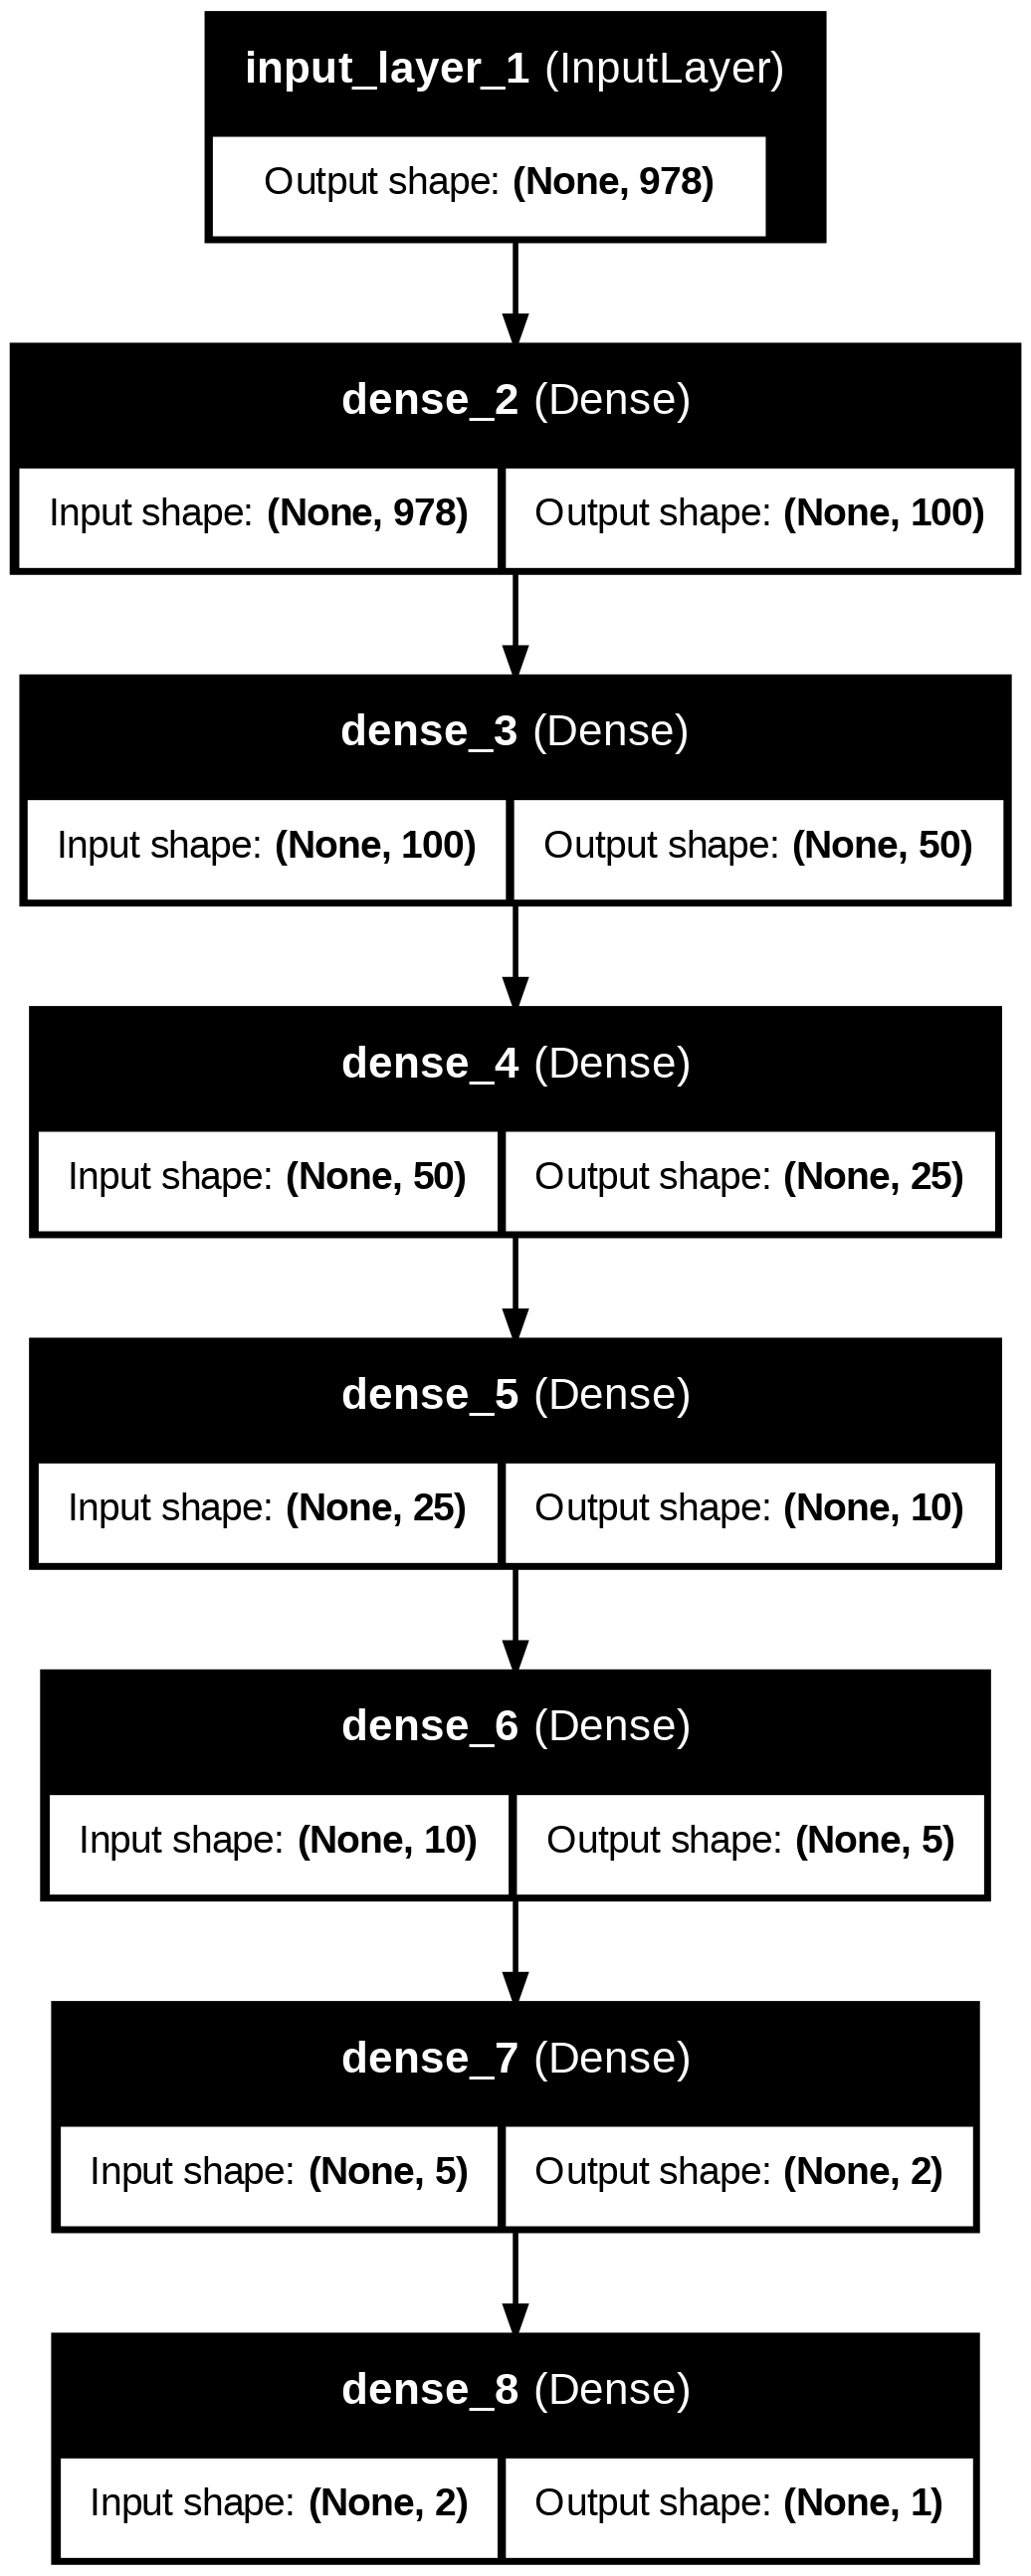

In [29]:
from keras.utils import plot_model
plot_model( model, to_file='model_plot.png', show_shapes=True, show_layer_names=True)

In [30]:
history = model.fit(X_train, y_train, batch_size=5, epochs=5, verbose=1, validation_split=0.2)

Epoch 1/5
765/765 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - loss: 3.6933 - mean_absolute_error: 3.6933 - val_loss: 2.3666 - val_mean_absolute_error: 2.3666
Epoch 2/5
765/765 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 2.1672 - mean_absolute_error: 2.1672 - val_loss: 2.2578 - val_mean_absolute_error: 2.2578
Epoch 3/5
765/765 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 1.8454 - mean_absolute_error: 1.8454 - val_loss: 2.1255 - val_mean_absolute_error: 2.1255
Epoch 4/5
765/765 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 1.6427 - mean_absolute_error: 1.6427 - val_loss: 1.9171 - val_mean_absolute_error: 1.9171
Epoch 5/5
765/765 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 1.5637 - mean_absolute_error: 1.5637 - val_loss: 1.9727 - val_mean_absolute_error: 1.9727


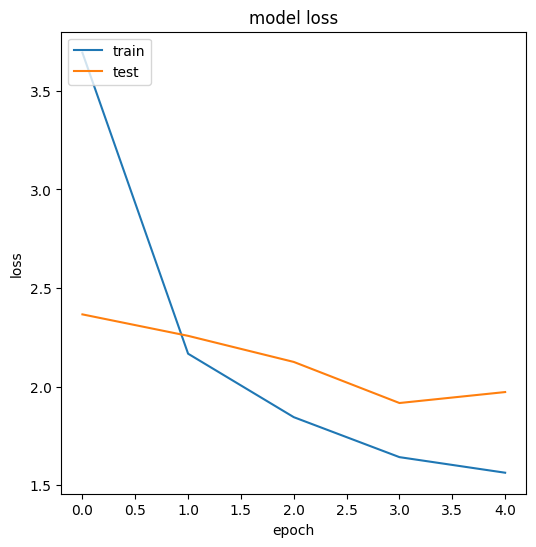

In [34]:
plt.rcParams['figure.figsize'] = [6,6]
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')

In [35]:
 y_prdeic = model.predict(X_test)

38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step


In [36]:
from sklearn import metrics

print('MAE:', metrics.mean_absolute_error(y_test, y_prdeic))
print('MSE:', metrics.mean_squared_error(y_test, y_prdeic))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, y_prdeic)))

MAE: 1.6429227590560913
MSE: 15.72438907623291
RMSE: 3.965398980712144


In [37]:
car_dataset['Price'].mean()

np.float64(9.47946835022429)

In [38]:
comparison_df = pd.DataFrame({'Actual Values': y_test.values.tolist(), 'Predicted Values': y_prdeic.tolist()})
comparison_df.head(10)

,Actual Values,Predicted Values
0,[8.25],[8.162429809570312]
1,[5.08],[5.151956081390381]
2,[4.5],[7.008269786834717]
3,[28.5],[25.432119369506836]
4,[7.25],[13.201000213623047]
5,[3.71],[3.33134388923645]
6,[22.95],[24.786270141601562]
7,[4.5],[3.6629154682159424]
8,[8.5],[7.73415994644165]
9,[19.92],[16.927627563476562]


In [39]:
X_test[1].shape

(978,)

In [42]:
single_point = X_test[1].reshape(1,-1)
single_point.shape



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


array([5.08])

In [44]:
model.predict(X_test[1].reshape(1,-1))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step


array([[5.151957]], dtype=float32)

In [45]:
y_test.values[1 ]

array([5.08])